# Quantum scrambling Born machine

A **Born machine** stores a probability distribution in the amplitudes of a quantum state:
measuring a parametrized state $|\psi(\boldsymbol\theta)\rangle$ in the computational basis
returns outcome $x$ with probability $p_{\boldsymbol\theta}(x)=|\langle x|\psi(\boldsymbol\theta)\rangle|^2$.
Training adjusts $\boldsymbol\theta$ so that $p_{\boldsymbol\theta}$ matches a target $q$.

The tension is that the scrambling which makes the output expressive is the same scrambling
that flattens the training gradients (the barren plateau). The **quantum scrambling Born
machine (QSBM)** removes the *hardware* side of that tension: a fixed, non-trainable
scrambling unitary supplies all the entanglement, and **only single-qubit rotations are
trained**. This notebook builds a QSBM in JAX and reproduces the layer-by-layer improvement
of the book figure.

Reference: M. Płodzień, *Quantum Scrambling Born Machine*, Phys. Rev. A (2026), arXiv:2602.17281.

## Architecture

Starting from $|0\rangle^{\otimes N_Q}$, each of $L$ layers applies

1. trainable single-qubit **pre-rotations** $R_x,R_z$ on every qubit,
2. the **fixed scrambler** $\hat U_S$ (the *same* unitary in every layer),
3. a trainable single-qubit **post-rotation** $R_y$ on every qubit.

$N_A$ ancilla qubits are traced out before measurement, giving a *mixed* output distribution
over the remaining $n=N_Q-N_A$ qubits (mixedness is an extra expressivity resource). Only the
rotation angles are trained; $\hat U_S$ is fixed. We use JAX so that the loss gradient comes
from automatic differentiation.

In [1]:
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

In [2]:
# System size and single-qubit gates (applied matrix-free on the state tensor)
N_Q, N_A = 8, 2            # total qubits, traced-out ancillas
N_SYS = N_Q - N_A          # measured qubits  ->  2**N_SYS bins
D = 2 ** N_Q

I2 = jnp.eye(2, dtype=jnp.complex128)
X = jnp.array([[0, 1], [1, 0]], jnp.complex128)
Y = jnp.array([[0, -1j], [1j, 0]], jnp.complex128)
Z = jnp.array([[1, 0], [0, -1]], jnp.complex128)

Rx = lambda t: jnp.cos(t / 2) * I2 - 1j * jnp.sin(t / 2) * X
Ry = lambda t: jnp.cos(t / 2) * I2 - 1j * jnp.sin(t / 2) * Y
Rz = lambda t: jnp.cos(t / 2) * I2 - 1j * jnp.sin(t / 2) * Z

def apply_1q(psi, U, q):
    "Apply a 2x2 gate U to qubit q of a state reshaped as (2,)*N_Q."
    return jnp.moveaxis(jnp.tensordot(U, psi, axes=([1], [q])), 0, q)

W0719 04:26:07.443613  387642 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0719 04:26:07.446133  387570 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [3]:
# The fixed scrambler: a Haar-random unitary (never trained).
# A finite-depth random circuit or analog Hamiltonian evolution would work equally well,
# as long as it reaches Haar-typical (Page-value) entanglement.
def haar_unitary(dim, seed):
    r = np.random.default_rng(seed)
    z = (r.standard_normal((dim, dim)) + 1j * r.standard_normal((dim, dim))) / np.sqrt(2)
    q, rr = np.linalg.qr(z)
    d = np.diagonal(rr)
    return jnp.array(q * (d / np.abs(d)))

U_S = haar_unitary(D, seed=0)

In [4]:
# Forward pass: |0...0> -> L layers of [pre Rx,Rz | U_S | post Ry] -> trace ancillas
def output_dist(theta, L):
    psi = jnp.zeros((D,), jnp.complex128).at[0].set(1.0)          # |0...0>
    for l in range(L):
        t = psi.reshape((2,) * N_Q)
        for q in range(N_Q):                                      # trainable pre-rotations
            t = apply_1q(t, Rx(theta[l, q, 0]), q)
            t = apply_1q(t, Rz(theta[l, q, 1]), q)
        psi = U_S @ t.ravel()                                     # fixed scrambler
        t = psi.reshape((2,) * N_Q)
        for q in range(N_Q):                                      # trainable post-rotation
            t = apply_1q(t, Ry(theta[l, q, 2]), q)
        psi = t.ravel()
    p_full = jnp.abs(psi) ** 2
    return p_full.reshape(2 ** N_SYS, 2 ** N_A).sum(axis=1)       # trace out the N_A ancillas

In [5]:
# Target: a five-peak Gaussian mixture over the 2**N_SYS bins
def make_target(n_bins, seed=123):
    x = np.arange(n_bins); r = np.random.RandomState(seed); p = np.zeros(n_bins)
    for i in range(5):
        c = (i + 0.5) * n_bins / 5; s = n_bins / 20; h = r.rand() + 0.5
        p += h * np.exp(-((x - c) ** 2) / (2 * s ** 2))
    return p / p.sum()

target = make_target(2 ** N_SYS)
q = jnp.array(target)

In [6]:
# Loss = negative log-likelihood; gradient by autodiff; trained with Adam.
def nll(theta, L):
    p = output_dist(theta, L)
    return -jnp.sum(q * jnp.log(jnp.clip(p, 1e-12, None)))

def train(L, steps=300, lr=0.02, seed=1):
    grad = jax.jit(jax.grad(nll), static_argnums=1)               # d/dtheta ; L is static
    r = np.random.default_rng(seed)
    theta = jnp.array(r.uniform(0, 2 * np.pi, (L, N_Q, 3)))
    m = jnp.zeros_like(theta); v = jnp.zeros_like(theta); b1, b2, eps = 0.9, 0.999, 1e-8
    for t in range(1, steps + 1):
        g = grad(theta, L)
        m = b1 * m + (1 - b1) * g; v = b2 * v + (1 - b2) * g * g
        theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta

# KLD is evaluated from a finite number of measurement shots (as on real hardware),
# which sets a floor on the achievable value.
def sampled_kld(p, n_shots=5000, seed=0):
    r = np.random.default_rng(seed); p = np.asarray(p); p = p / p.sum()
    phat = (r.multinomial(n_shots, p) + 1.0) / (n_shots + p.size)
    return float(np.sum(target * np.log(np.clip(target, 1e-12, None) / phat)))

In [7]:
# Sweep the number of trainable layers L (only single-qubit rotations are trained)
Ls = [1, 2, 3, 4, 6]
klds, dists = [], {}
for L in Ls:
    theta = train(L)
    p = np.array(output_dist(theta, L))
    klds.append(sampled_kld(p)); dists[L] = p
    print(f"L={L}:  KLD = {klds[-1]:.3f}")

L=1:  KLD = 0.057


L=2:  KLD = 0.020


L=3:  KLD = 0.012


L=4:  KLD = 0.008


L=6:  KLD = 0.009


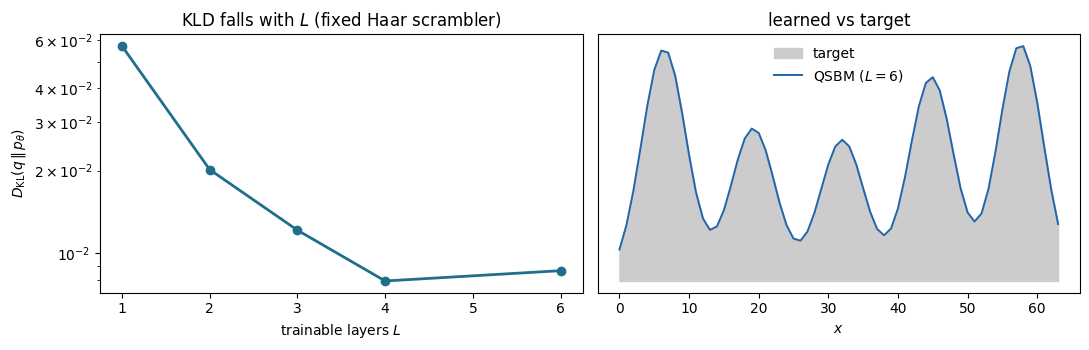

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(Ls, klds, "o-", color="#1f6f8b", lw=2)
ax[0].set_yscale("log"); ax[0].set_xlabel("trainable layers $L$")
ax[0].set_ylabel(r"$D_{\mathrm{KL}}(q\,\|\,p_\theta)$")
ax[0].set_title("KLD falls with $L$ (fixed Haar scrambler)")

xb = np.arange(2 ** N_SYS)
ax[1].fill_between(xb, target, color="0.8", label="target")
ax[1].plot(xb, dists[max(Ls)], color="#2166ac", lw=1.4, label=f"QSBM ($L={max(Ls)}$)")
ax[1].set_xlabel("$x$"); ax[1].set_yticks([]); ax[1].set_title("learned vs target")
ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## What we see, and where it breaks

- **More layers help.** The KLD falls steadily with $L$: each single-qubit layer reshapes the
  fixed, already-scrambled state closer to the target, with *no trainable entangling gate at all*.
  The whole parameter budget goes to the single-qubit readout.
- **It does not evade the barren plateau.** The trainable generators of one layer span only
  $\mathfrak{su}(2)^{\oplus N}$, but the state entering that layer is Haar-scrambled, so the
  gradient variance still decays like $\mathcal O(2^{-N})$ (the same second-moment concentration
  as any global cost). What the QSBM saves is the *hardware* cost of trainable multi-qubit gates,
  not the trainability itself.
- **The scrambler only needs Haar-typical entanglement.** Once the half-chain entropy reaches the
  Page value, the converged quality is set by that entropy alone; a finite-depth brickwork circuit
  or analog spin-chain evolution matches an ideal Haar unitary.
- **Finite shots set a floor.** The KLD is read from $5000$ measurement shots here, so it
  saturates at a nonzero floor even for a perfect model — the sampling cost that the barren-plateau
  concentration reappears as.

Try: replace `U_S` with a shallow random circuit (few entangling layers) and watch the KLD stall
above the Haar level until the circuit is deep enough to scramble.